In [1]:
import pandas as pd

train_df = pd.read_json("skills_assessment_data/train.json")
test_df  = pd.read_json("skills_assessment_data/test.json")

print(train_df.head())
print(test_df.head())

                                                text  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1
                                                text  label
0  I went and saw this movie last night after bei...      1
1  Actor turned director Bill Paxton follows up h...      1
2  As a recreational golfer with some knowledge o...      1
3  I saw this film in a sneak preview, and it is ...      1
4  Bill Paxton has taken the true story of the 19...      1


<Axes: xlabel='label', ylabel='count'>

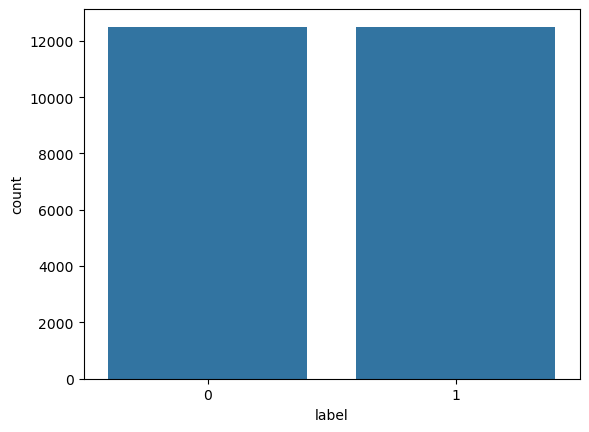

In [2]:
import seaborn as sns

sns.countplot(x = 'label', data = train_df)

In [3]:
train_df['text'][1]

'Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from going to school, work, or vote for the matter. Most people think of the homeless as just a lost cause while worrying about things such as racism, the war on Iraq, pressuring kids to succeed, technology, the elections, inflation, or worrying if they\'ll be next to end up on the streets.<br /><br />But what if you were given a bet to live on the streets for a month without the luxuries you once had from a home, the entertainment sets, a bathroom, pictures on the wall, a computer, and everything you once treasure to see what it\'s like to be homeless? That is Goddard Bolt\'s lesson.<br /><br />Mel Brooks (who directs) who stars as Bolt plays a rich man who has everything in the world until deciding to make a bet with a sissy rival (Jeffery Tambor) to see if he can live in the streets for thirty days withou

In [4]:
import re
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r"[^a-zA-Z0-9\s\!\$\?']", " ", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [5]:
train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

In [6]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
#tokenizer = Tokenizer( oov_token="<OOV>")


In [25]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_length, padding="post")

In [27]:
from sklearn.model_selection import train_test_split

X_train_pad, X_val, y_train, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42
)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(20000, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

In [29]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.5122 - loss: 0.6908 - val_accuracy: 0.5320 - val_loss: 0.6820
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.5476 - loss: 0.6713 - val_accuracy: 0.5278 - val_loss: 0.6775
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5653 - loss: 0.6313 - val_accuracy: 0.5408 - val_loss: 0.6812
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8023 - loss: 0.4424 - val_accuracy: 0.8542 - val_loss: 0.3571
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9196 - loss: 0.2346 - val_accuracy: 0.8750 - val_loss: 0.3219


In [31]:
model.evaluate(X_test_pad, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8603 - loss: 0.3676


[0.3676454424858093, 0.8602799773216248]

In [32]:
model.save("sentiment_lstm_model.keras")

In [33]:
import joblib

joblib.dump(model, "sentiment_model.joblib")

['sentiment_model.joblib']